# GSPO Fine-tuning on GSM8K dataset


## Part 1: Setup and Environment



In [ ]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import warnings
warnings.filterwarnings('ignore')

from trl import GRPOConfig, GRPOTrainer
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainerCallback
)
from datasets import load_dataset

import torch
from typing import Optional, List
import numpy as np
import re
import logging
from datetime import datetime
from dataclasses import dataclass, field
import matplotlib.pyplot as plt

print("✅ All imports successful")

[2026-09-22 09:43:32] INFO font_manager.py:1639: generated new fontManager


✅ All imports successful


### 1.2 Configure Logging and Check GPU


In [ ]:
logging.basicConfig(level=logging.ERROR)
logging.getLogger('transformers').setLevel(logging.ERROR)
logging.getLogger('trl').setLevel(logging.ERROR)
logging.getLogger('datasets').setLevel(logging.ERROR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

✅ Device: cuda
   GPU: 
   Memory: 191.7 GB


## Part 2: Training Configuration

### 2.1 Define Training Configuration


In [ ]:
@dataclass
class GSPOTrainingConfig:
    """GSPO (Group Sequence Policy Optimization) training configuration"""
    model_name: str = field(default="deepseek-ai/deepseek-math-7b-base")
    output_dir: str = field(default="./gspo_finetuned_model")

    # Training parameters
    num_train_epochs: int = field(default=1)
    per_device_train_batch_size: int = field(default=2)
    gradient_accumulation_steps: int = field(default=4)
    learning_rate: float = field(default=1e-5)

    # GSPO-specific: Generation parameters
    num_generations: int = field(default=4)
    temperature: float = field(default=0.7)
    max_new_tokens: int = field(default=256)

    # GSPO-specific: Policy Optimization parameters
    steps_per_generation: int = field(default=16)
    epsilon: float = field(default=3e-4)
    epsilon_high: float = field(default=4e-4)

    # Dataset parameters
    max_prompt_length: int = field(default=512)
    train_split_ratio: float = field(default=0.8)

    # Evaluation
    eval_steps: int = field(default=20)
    save_steps: int = field(default=100)
    logging_steps: int = field(default=5)

config = GSPOTrainingConfig(
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=1e-5,
    num_generations=4,
    temperature=0.7,
    max_new_tokens=256,
    eval_steps=20,
    steps_per_generation=16,
    epsilon=2e-4,
    epsilon_high=5e-4,
    logging_steps=5,
)

print("✅ GSPO Configuration created")

✅ GSPO Configuration created


## Part 3: Reward Model



In [ ]:
class GSM8KRewardSignal:
    """Reward model for GSM8K mathematical reasoning in GSPO"""

    def extract_numerical_answer(self, text: str) -> Optional[float]:
        """Extract numerical answer from text"""

        # Strategy 1: Look for #### (GSM8K format)
        if "####" in text:
            answer = text.split("####")[-1].strip()
            answer = answer.replace(',', '').replace('$', '')
            try:
                return float(answer)
            except:
                return None

        # Strategy 2: Regex patterns
        patterns = [
            r"(?:The answer is|answer:|Answer:)\s*\$?([+-]?\d+(?:,\d{3})*(?:\.\d+)?)",
            r"(?:equals?|=)\s*\$?([+-]?\d+(?:,\d{3})*(?:\.\d+)?)",
            r"(?:total|sum|result)\s*(?:is|:|=)?\s*\$?([+-]?\d+(?:,\d{3})*(?:\.\d+)?)",
        ]

        for pattern in patterns:
            matches = re.findall(pattern, text, re.IGNORECASE)
            if matches:
                try:
                    return float(matches[-1].replace(',', ''))
                except:
                    continue

        # Strategy 3: Any number
        numbers = re.findall(r'([+-]?\d+(?:,\d{3})*(?:\.\d+)?)', text)
        if numbers:
            try:
                return float(numbers[-1].replace(',', ''))
            except:
                pass

        return None

    def compute_reward(self, response: str, correct_answer: float, question: str = None) -> float:
        """Compute reward for a response"""
        predicted = self.extract_numerical_answer(response)

        has_calculation = any(word in response.lower()
                              for word in ['=', '+', '-', '*', '/', 'multiply', 'divide', 'add', 'subtract'])
        has_steps = len(response.split('.')) > 2
        has_numbers = bool(re.search(r'\d', response))

        # No parseable answer
        if predicted is None:
            if len(response) > 200 and has_calculation and has_numbers:
                return 0.2
            elif has_calculation and has_numbers:
                return 0.1
            else:
                return 0.05

        # Correct answer
        if abs(predicted - correct_answer) < 0.01:
            return 1.0 + (0.2 if has_steps else 0)

        # Wrong answer - partial credit
        relative_error = abs(predicted - correct_answer) / (abs(correct_answer) + 1e-10)

        if relative_error < 0.1:
            reward = 0.8
        elif relative_error < 0.3:
            reward = 0.5
        else:
            reward = 0.15

        if has_calculation and has_steps:
            reward += 0.1

        return reward

reward_model = GSM8KRewardSignal()
print("✅ Reward model initialized")

✅ Reward model initialized


## Part 4: Data Processing





In [ ]:
def truncate_prompt(text: str, tokenizer, max_length: int) -> str:
    """Truncate prompt from the left to keep end context"""
    tokens = tokenizer(text, add_special_tokens=False)['input_ids']
    if len(tokens) <= max_length:
        return text
    truncated_tokens = tokens[-max_length:]
    return tokenizer.decode(truncated_tokens, skip_special_tokens=True)

def prepare_gspo_dataset(config: GSPOTrainingConfig, tokenizer):
    """Load and prepare GSM8K dataset for GSPO training"""
    print("Loading GSM8K dataset...")
    dataset = load_dataset("openai/gsm8k", "main")
    train_data_full = dataset["train"]

    # Split into train/validation
    total_size = len(train_data_full)
    train_size = int(total_size * config.train_split_ratio)

    indices = list(range(total_size))

    train_data = train_data_full.select(indices[:train_size])
    eval_data = train_data_full.select(indices[train_size:])

    def process_example(example):
        question = example['question']
        answer_text = example['answer']

        if "####" in answer_text:
            answer = answer_text.split("####")[-1].strip()
            answer = answer.replace(',', '').replace('$', '')
            try:
                answer_num = float(answer)
            except:
                answer_num = 0.0
        else:
            answer_num = 0.0

        prompt = f"Question: {question}\n\nLet's solve this step-by-step:\n"
        prompt = truncate_prompt(prompt, tokenizer, config.max_prompt_length)

        return {
            'prompt': prompt,
            'question': question,
            'answer': answer_num,
            'answer_text': answer_text
        }

    train_dataset = train_data.map(process_example)
    eval_dataset = eval_data.map(process_example)

    return train_dataset, eval_dataset

print("✅ Utility functions defined")

✅ Utility functions defined


## Part 5: Evaluation System



In [ ]:
class GSM8KEvaluationCallback(TrainerCallback):
    """Custom callback to evaluate on GSM8K test set during training"""

    def __init__(self, tokenizer, test_dataset, batch_size=32, sample_size=0.2):
        self.tokenizer = tokenizer
        self.test_dataset = test_dataset
        self.batch_size = batch_size
        self.sample_size = sample_size
        self.logger = logging.getLogger(__name__)

    def on_step_end(self, args, state, control, model=None, **kwargs):
        """Called at the end of each training step"""
        if state.global_step > 0 and state.global_step % args.eval_steps == 0:
            self._run_evaluation(state, kwargs.get('model', model))

    def _run_evaluation(self, state, model):
        """Run the actual evaluation"""
        if model is None:
            self.logger.error("❌ [EVAL-ERROR] Model is None - cannot evaluate")
            return

        try:
            model.eval()
            model.train()

        except Exception as e:
            self.logger.error(f"❌ [EVAL-ERROR] {type(e).__name__}: {e}")
            import traceback
            self.logger.error(traceback.format_exc())

print("✅ Evaluation callback defined")

✅ Evaluation callback defined


## Part 6: Load Model and Tokenizer


In [ ]:
print("Loading model and tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(config.model_name, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    config.model_name,
    trust_remote_code=True,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    use_safetensors=True,
)

if hasattr(model, 'gradient_checkpointing_enable'):
    model.gradient_checkpointing_enable()

print(f"✅ Model loaded")
print(f"   Dtype: {next(model.parameters()).dtype}")

Loading model and tokenizer...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Model loaded
   Dtype: torch.bfloat16


## Part 7: Prepare Training Data


In [ ]:
train_dataset, eval_dataset = prepare_gspo_dataset(config, tokenizer)
print(f"✅ Datasets prepared: train={len(train_dataset)}, eval={len(eval_dataset)}")

# Load test dataset for evaluation
test_dataset = None
try:
    gsm8k = load_dataset("openai/gsm8k", "main")
    test_dataset = gsm8k["test"]
    print(f"✅ Test dataset loaded: {len(test_dataset)} examples")
except:
    print("⚠️  Test dataset not loaded")

Loading GSM8K dataset...


Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Map:   0%|          | 0/5978 [00:00<?, ? examples/s]

Map:   0%|          | 0/1495 [00:00<?, ? examples/s]

✅ Datasets prepared: train=5978, eval=1495
✅ Test dataset loaded: 1319 examples


# Part 8: Configure GRPO/GSPO Trainer



In [ ]:
# Build prompt lookup dictionary
prompt2ans = {item['prompt']: (item['answer'], item['question'])
              for item in train_dataset}

gspo_config = GRPOConfig(
    # GSPO CORE PARAMETERS
    importance_sampling_level="sequence",
    loss_type="grpo",
    beta=0.0,
    epsilon=config.epsilon,
    epsilon_high=config.epsilon_high,
    steps_per_generation=config.steps_per_generation,

    # Training
    output_dir=config.output_dir,
    num_train_epochs=config.num_train_epochs,
    per_device_train_batch_size=config.per_device_train_batch_size,
    gradient_accumulation_steps=config.gradient_accumulation_steps,
    learning_rate=config.learning_rate,

    # Generation
    num_generations=config.num_generations,
    temperature=config.temperature,
    generation_kwargs={
        "max_tokens": config.max_new_tokens,
        "temperature": config.temperature,
        "top_p": 0.95,
    },

    use_vllm=True,
    vllm_mode="colocate",
    vllm_gpu_memory_utilization=0.4,

    # Optimization
    lr_scheduler_type="linear",
    warmup_ratio=0.03,
    max_grad_norm=1.0,
    weight_decay=0.1,

    # Logging
    logging_steps=50,
    eval_steps=config.eval_steps,
    save_steps=config.save_steps,
    seed=42,
    disable_tqdm=True,
    log_level="error",
    log_level_replica="error",

    # Device
    fp16=False,
    bf16=True if torch.cuda.is_available() else False,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to=[],
)

print("✅ GSPO configuration created")

✅ GSPO configuration created


## Part 9: Define Reward Function




In [ ]:
def compute_rewards(prompts: List[str], completions: List[str], **kwargs):
    """Compute rewards for GSPO training"""
    raw_rewards = [0.0] * len(completions)

    prompt_to_indices = {}
    for idx, p in enumerate(prompts):
        prompt_to_indices.setdefault(p, []).append(idx)

    for prompt, idx_list in prompt_to_indices.items():
        correct_answer, question = prompt2ans.get(prompt, (0.0, ""))

        for idx in idx_list:
            comp = completions[idx]
            r = reward_model.compute_reward(comp, correct_answer, question)
            raw_rewards[idx] = float(r)

    return raw_rewards

print("✅ Reward function defined")

✅ Reward function defined


## Part 10: Training Progress Tracking



In [ ]:
class GSPOProgressCallback(TrainerCallback):
    """Evaluate and plot GSPO training progress - minimal logging style"""

    def __init__(self, tokenizer, eval_dataset, eval_frequency_steps=20):
        self.tokenizer = tokenizer
        self.eval_dataset = eval_dataset
        self.eval_frequency_steps = eval_frequency_steps
        self.steps = []
        self.accuracies = []
        self.rewards = []

    def on_step_end(self, args, state, control, **kwargs):
        if state.global_step > 0 and state.global_step % self.eval_frequency_steps == 0:
            self._evaluate(state, kwargs.get('model'))

        if state.global_step >= 80:
            control.should_training_stop = True

    def _evaluate(self, state, model):
        if model is None:
            return

        try:
            model.eval()

            # Evaluate on 50 random samples
            num_samples = min(50, len(self.eval_dataset))
            indices = np.random.choice(len(self.eval_dataset), num_samples, replace=False)

            correct = 0
            rewards = []

            for idx in indices:
                example = self.eval_dataset[int(idx)]
                prompt = example['prompt']
                correct_answer = example['answer']

                inputs = self.tokenizer(prompt, return_tensors='pt').to(model.device)
                with torch.no_grad():
                    outputs = model.generate(
                        **inputs,
                        max_new_tokens=256,
                        temperature=0.7,
                        top_p=0.95,
                        do_sample=False,
                    )

                response = self.tokenizer.decode(
                    outputs[0][inputs['input_ids'].shape[1]:],
                    skip_special_tokens=True
                )

                reward = reward_model.compute_reward(response, correct_answer, example['question'])
                rewards.append(reward)

                if reward >= 0.9:
                    correct += 1

            accuracy = (correct / num_samples * 100) if num_samples > 0 else 0
            mean_reward = np.mean(rewards)

            self.steps.append(state.global_step)
            self.accuracies.append(accuracy)
            self.rewards.append(mean_reward)

            # Simple output like Unsloth - just the key metrics
            print(f"Step {state.global_step} | Accuracy {accuracy:.1f}% | Reward {mean_reward:.4f}")
            self._plot()

            model.train()

        except Exception as e:
            print(f"Eval error: {e}")

    def _plot(self):
        """Save progress plots"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

        ax1.plot(self.steps, self.accuracies, 'b-o', linewidth=2, markersize=6)
        ax1.set_xlabel('Step', fontsize=11)
        ax1.set_ylabel('Accuracy (%)', fontsize=11)
        ax1.set_title('GSPO Training: Accuracy', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim([0, 100])

        ax2.plot(self.steps, self.rewards, 'g-s', linewidth=2, markersize=6)
        ax2.set_xlabel('Step', fontsize=11)
        ax2.set_ylabel('Mean Reward', fontsize=11)
        ax2.set_title('GSPO Training: Mean Reward', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim([0, 1.0])

        plt.tight_layout()
        plt.savefig('gspo_progress.png', dpi=100, bbox_inches='tight')
        plt.show()

print("✅ Callback defined")

✅ Callback defined


# Part 11: Initialize Trainer


In [ ]:
trainer = GRPOTrainer(
    model=model,
    reward_funcs=compute_rewards,
    args=gspo_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
)

if eval_dataset is not None:
    progress_callback = GSPOProgressCallback(
        tokenizer=tokenizer,
        eval_dataset=eval_dataset,
        eval_frequency_steps=config.eval_steps,
    )
    trainer.add_callback(progress_callback)

print("✅ GSPO Trainer initialized and ready!")

[aiter] import [module_aiter_enum] under /usr/local/lib/python3.12/dist-packages/aiter/jit/module_aiter_enum.so
[2026-09-22 09:45:03] INFO core.py:477: import [module_aiter_enum] under /usr/local/lib/python3.12/dist-packages/aiter/jit/module_aiter_enum.so


[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0


Loading pt checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


[aiter] import [module_rmsnorm] under /usr/local/lib/python3.12/dist-packages/aiter/jit/module_rmsnorm.so
[2026-09-22 09:45:29] INFO core.py:477: import [module_rmsnorm] under /usr/local/lib/python3.12/dist-packages/aiter/jit/module_rmsnorm.so
Capturing CUDA graphs (mixed prefill-decode, FULL): 100%|██████████| 11/11 [00:01<00:00,  6.40it/s]


✅ GSPO Trainer initialized and ready!


## Part 12: Run Training




GSPO TRAINING

Step 20 | Accuracy 40.0% | Reward 0.6300


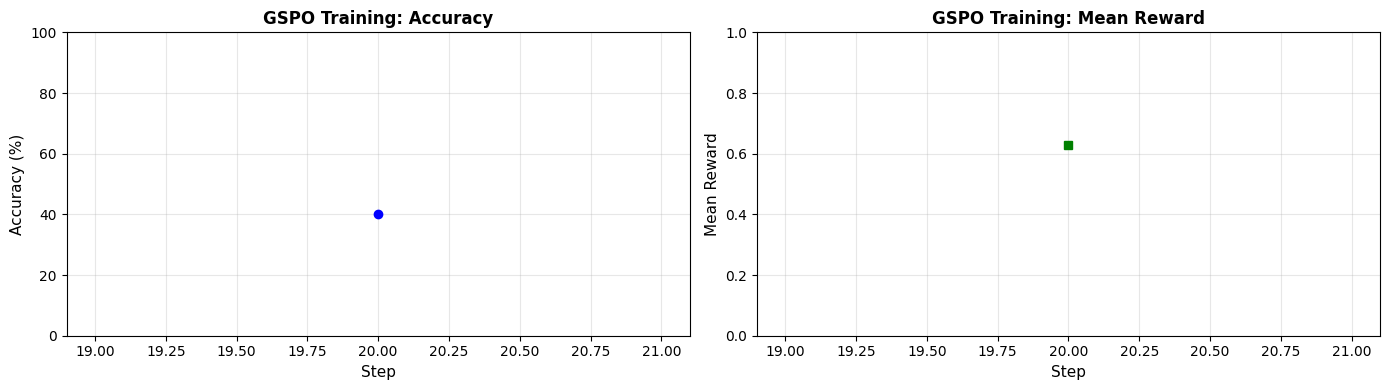

Step 40 | Accuracy 36.0% | Reward 0.5790


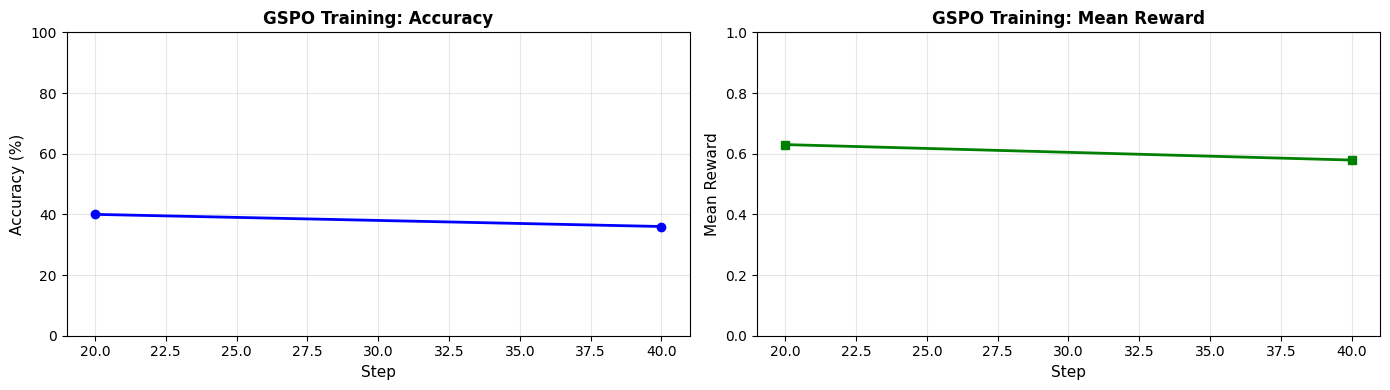

{'loss': 0.0015, 'grad_norm': 0.0113525390625, 'learning_rate': 5.444444444444445e-06, 'num_tokens': 129996.0, 'completions/mean_length': 233.07692307692307, 'completions/min_length': 109.76923076923077, 'completions/max_length': 256.0, 'completions/clipped_ratio': 0.7019230769230769, 'completions/mean_terminated_length': 180.1594003530649, 'completions/min_terminated_length': 109.76923076923077, 'completions/max_terminated_length': 240.0, 'rewards/compute_rewards/mean': 0.615504828783182, 'rewards/compute_rewards/std': 0.4453050677592938, 'reward': 0.615504828783182, 'reward_std': 0.4453050654668074, 'frac_reward_zero_std': 0.21153846153846154, 'sampling/sampling_logp_difference/mean': 0.045023986926445596, 'sampling/sampling_logp_difference/max': 1.2320304742226234, 'sampling/importance_sampling_ratio/min': 0.00015019861419974544, 'sampling/importance_sampling_ratio/mean': 0.06752415947042979, 'sampling/importance_sampling_ratio/max': 0.6219236312004236, 'entropy': 0.3429793062061071

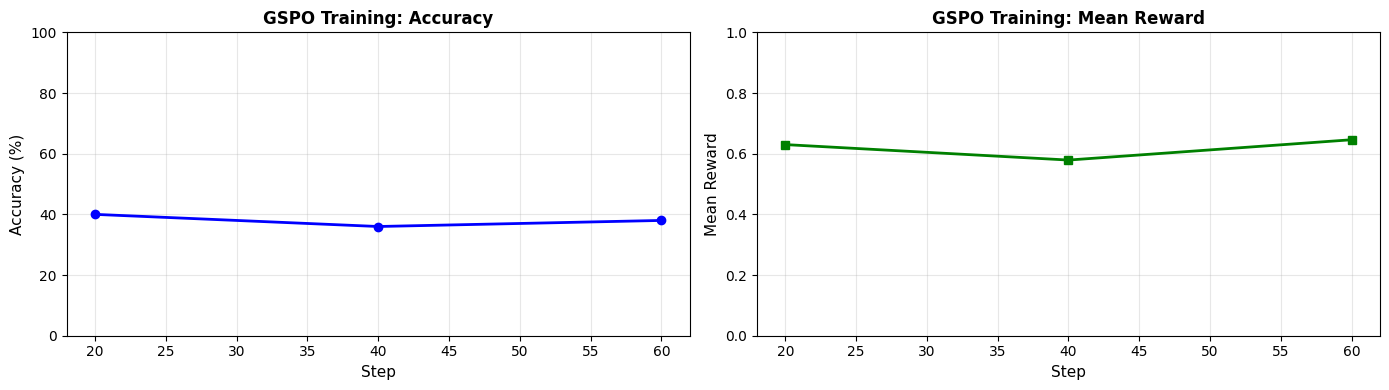

Step 80 | Accuracy 48.0% | Reward 0.7090


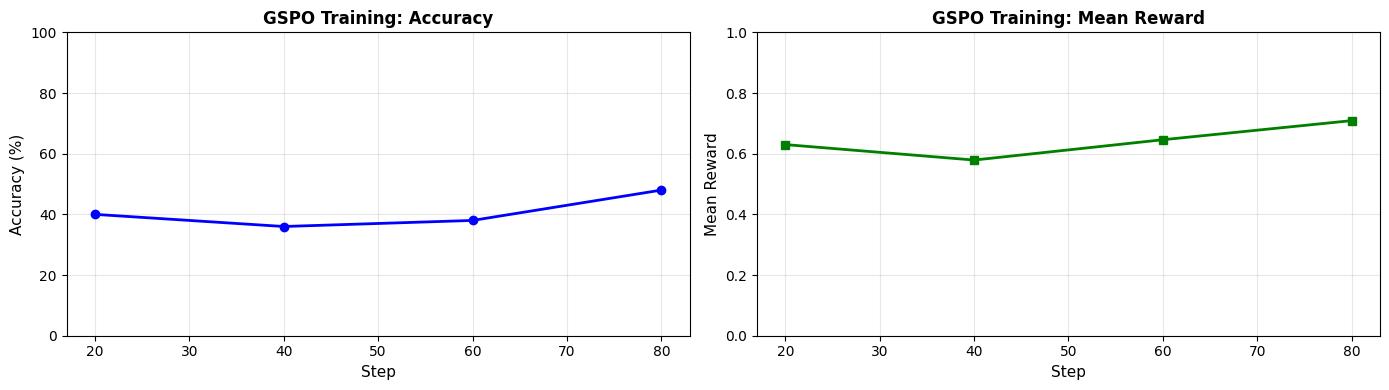

{'train_runtime': 909.3109, 'train_samples_per_second': 6.574, 'train_steps_per_second': 3.286, 'train_loss': 0.0016098013147711754, 'entropy': 0.3118717547506094, 'clip_ratio/low_mean': 0.14166666666666666, 'clip_ratio/low_min': 0.14166666666666666, 'clip_ratio/high_mean': 0.15, 'clip_ratio/high_max': 0.15, 'clip_ratio/region_mean': 0.2916666666666667, 'step_time': 1.208636091897885, 'num_tokens': 197698.0, 'completions/mean_length': 227.86607142857142, 'completions/min_length': 125.85714285714286, 'completions/max_length': 256.0, 'completions/clipped_ratio': 0.6160714285714286, 'completions/mean_terminated_length': 185.0729261125837, 'completions/min_terminated_length': 125.85714285714286, 'completions/max_terminated_length': 246.28571428571428, 'rewards/compute_rewards/mean': 0.677678610597338, 'rewards/compute_rewards/std': 0.4479245202881949, 'reward': 0.677678610597338, 'reward_std': 0.44792450751577106, 'frac_reward_zero_std': 0.23214285714285715, 'sampling/sampling_logp_differe

In [ ]:
print("\n" + "="*60)
print("GSPO TRAINING")
print("="*60 + "\n")

trainer.train()

print("\n✅ Training complete!")